# 📊 Engineering Productivity & Code Quality Analytics — Standard EDA

> **Company:** NovaTech Solutions  
> **Domain:** Software Engineering Analytics (2023–2025)  
> **Dataset:** `cleaned_engineering_data.csv` (25,000 records × 59 columns)  
> **Author:** Tanish Jain



In [18]:
# Import Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


print("✅ Standard EDA environment initialized.")


✅ Standard EDA environment initialized.


In [19]:
# Load Cleaned Dataset
df = pd.read_csv('cleaned_engineering_data.csv')
print(f"Dataset Loaded Successfully: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset Loaded Successfully: 25,000 rows x 59 columns


## Question 1: Which engineering team has the highest productivity?

/var/folders/h4/9ytflx8j06v6w6t3cpsjkj7m0000gn/T/ipykernel_11427/2225281696.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tp, x='Team', y='Velocity', palette='Blues_d')


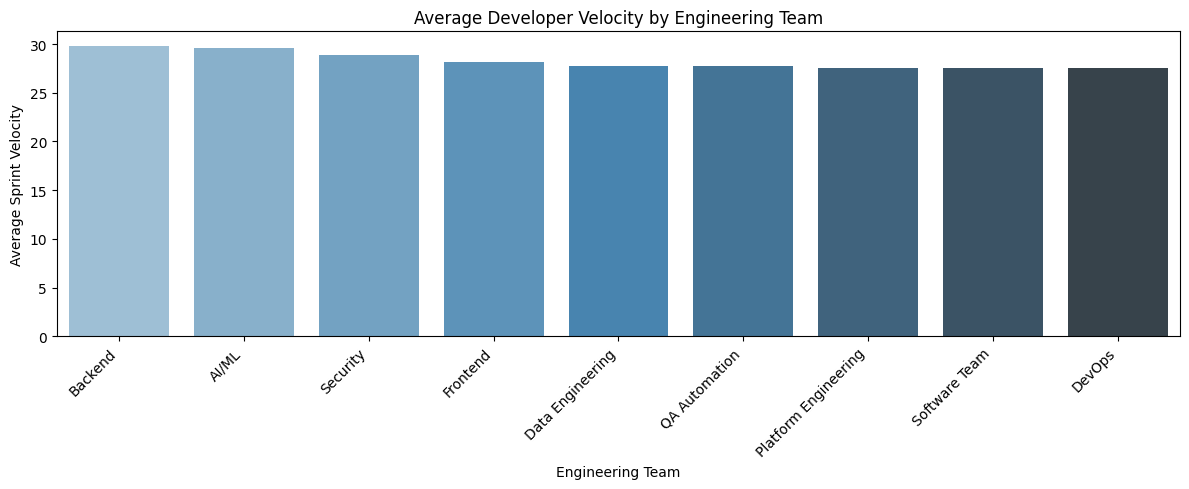

                Team  Velocity
             Backend 29.812526
               AI/ML 29.566284
            Security 28.838266
            Frontend 28.107614
    Data Engineering 27.755193
       QA Automation 27.722699
Platform Engineering 27.539747
       Software Team 27.527778
              DevOps 27.512042


In [20]:
tp = df.groupby('Team')['Velocity'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 5), dpi=100)
sns.barplot(data=tp, x='Team', y='Velocity', palette='Blues_d')
plt.title("Average Developer Velocity by Engineering Team")
plt.xlabel("Engineering Team")
plt.ylabel("Average Sprint Velocity")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(tp.to_string(index=False))

## Question 2: Which programming language is associated with the highest number of bugs?

/var/folders/h4/9ytflx8j06v6w6t3cpsjkj7m0000gn/T/ipykernel_11427/4091358007.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lb, x='Language', y='Bugs_Introduced', palette='Reds_r')


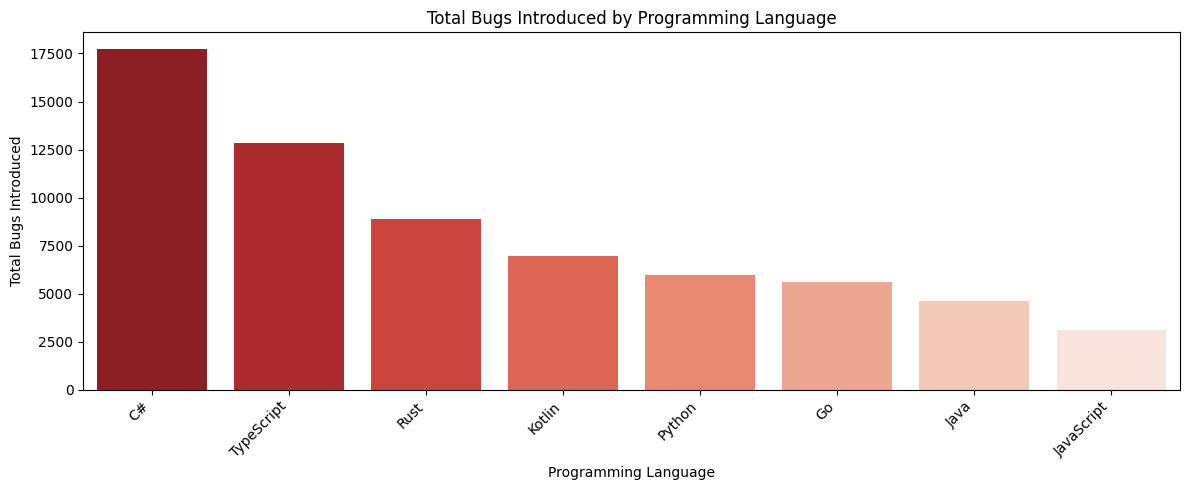

  Language  Bugs_Introduced
        C#          17715.0
TypeScript          12842.0
      Rust           8891.0
    Kotlin           6947.0
    Python           5978.0
        Go           5602.0
      Java           4633.0
JavaScript           3106.0


In [21]:
lb = df.groupby('Language')['Bugs_Introduced'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 5), dpi=100)
sns.barplot(data=lb, x='Language', y='Bugs_Introduced', palette='Reds_r')
plt.title("Total Bugs Introduced by Programming Language")
plt.xlabel("Programming Language")
plt.ylabel("Total Bugs Introduced")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(lb.to_string(index=False))

## Question 3: Does developer experience reduce the number of bugs?

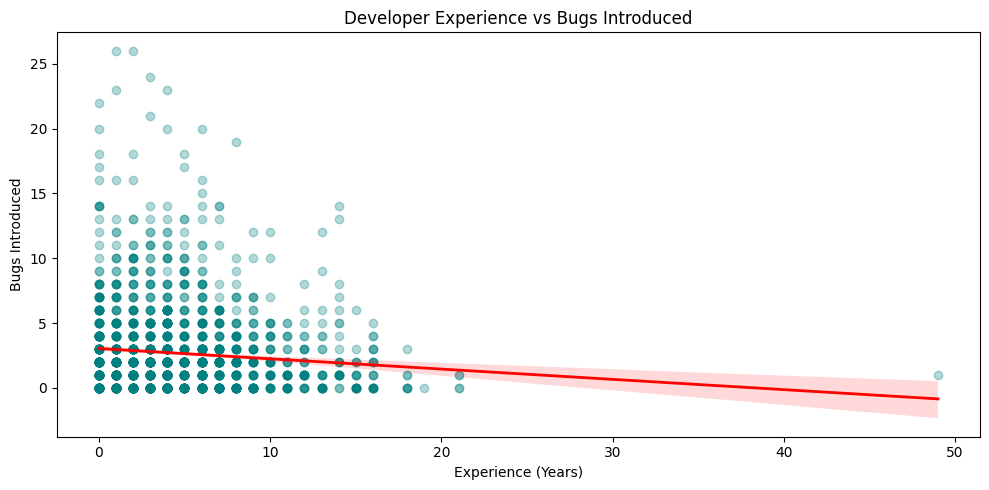

In [22]:
sample = df.sample(2000, random_state=42)

plt.figure(figsize=(10, 5), dpi=100)
sns.regplot(data=sample, x='Experience_Years', y='Bugs_Introduced',
            scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red', 'linewidth':2})
plt.title("Developer Experience vs Bugs Introduced")
plt.xlabel("Experience (Years)")
plt.ylabel("Bugs Introduced")
plt.tight_layout()
plt.show()

## Question 4: Which repositories have the highest number of open issues?

/var/folders/h4/9ytflx8j06v6w6t3cpsjkj7m0000gn/T/ipykernel_11427/2661357234.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ti, y='Repository_Name', x='Open_Issues', palette='Purples_r')


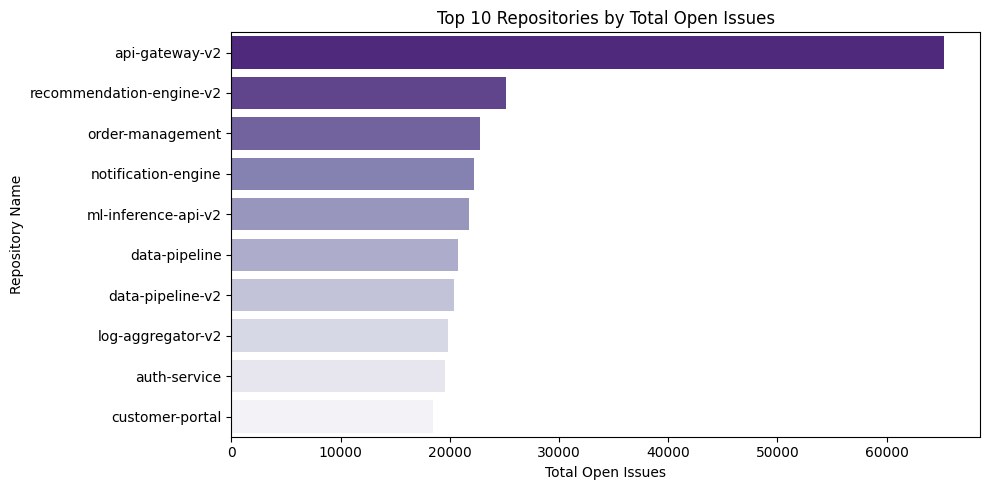

         Repository_Name  Open_Issues
          api-gateway-v2      65279.0
recommendation-engine-v2      25162.0
        order-management      22800.0
     notification-engine      22216.0
     ml-inference-api-v2      21724.0
           data-pipeline      20723.0
        data-pipeline-v2      20355.0
       log-aggregator-v2      19826.0
            auth-service      19596.0
         customer-portal      18437.0


In [23]:
ti = df.groupby('Repository_Name')['Open_Issues'].sum().nlargest(10).reset_index()

plt.figure(figsize=(10, 5), dpi=100)
sns.barplot(data=ti, y='Repository_Name', x='Open_Issues', palette='Purples_r')
plt.title("Top 10 Repositories by Total Open Issues")
plt.xlabel("Total Open Issues")
plt.ylabel("Repository Name")
plt.tight_layout()
plt.show()

print(ti.to_string(index=False))

## Question 5: Is there a relationship between code churn and bugs introduced?

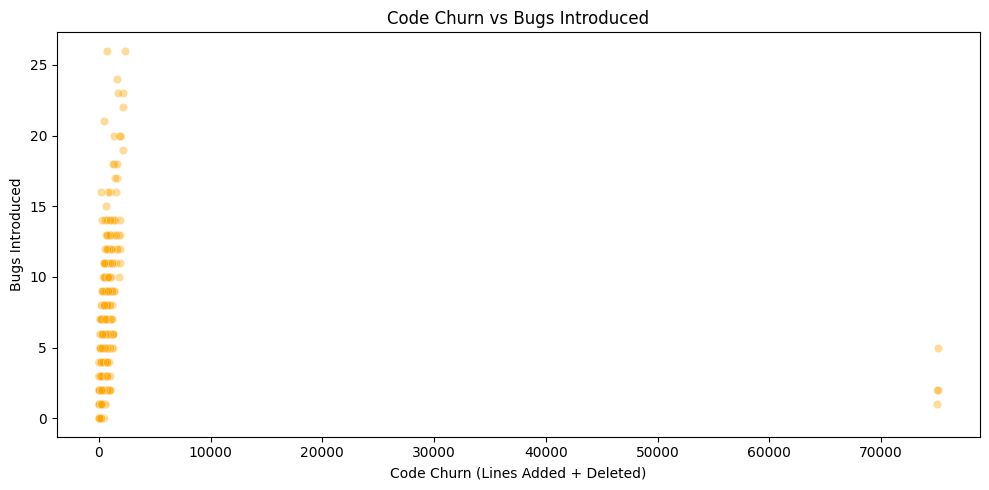

In [24]:
sample = df.sample(2000, random_state=42)

plt.figure(figsize=(10, 5), dpi=100)
sns.scatterplot(data=sample, x='Code_Churn', y='Bugs_Introduced', alpha=0.4, color='orange')
plt.title("Code Churn vs Bugs Introduced")
plt.xlabel("Code Churn (Lines Added + Deleted)")
plt.ylabel("Bugs Introduced")
plt.tight_layout()
plt.show()

## Question 6: Does higher test coverage lead to fewer production bugs?

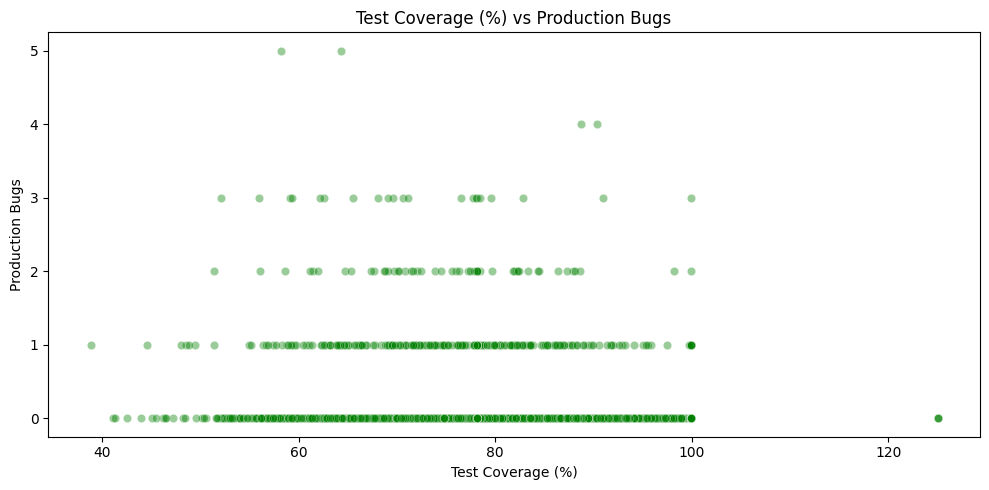

In [25]:
sample = df.sample(2000, random_state=42)

plt.figure(figsize=(10, 5), dpi=100)
sns.scatterplot(data=sample, x='Test_Coverage', y='Production_Bugs', alpha=0.4, color='green')
plt.title("Test Coverage (%) vs Production Bugs")
plt.xlabel("Test Coverage (%)")
plt.ylabel("Production Bugs")
plt.tight_layout()
plt.show()

## Question 7: Which sprint had the highest number of bugs?

/var/folders/h4/9ytflx8j06v6w6t3cpsjkj7m0000gn/T/ipykernel_11427/1583016237.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sb, x='Sprint', y='Bugs_Introduced', palette='Reds_r')


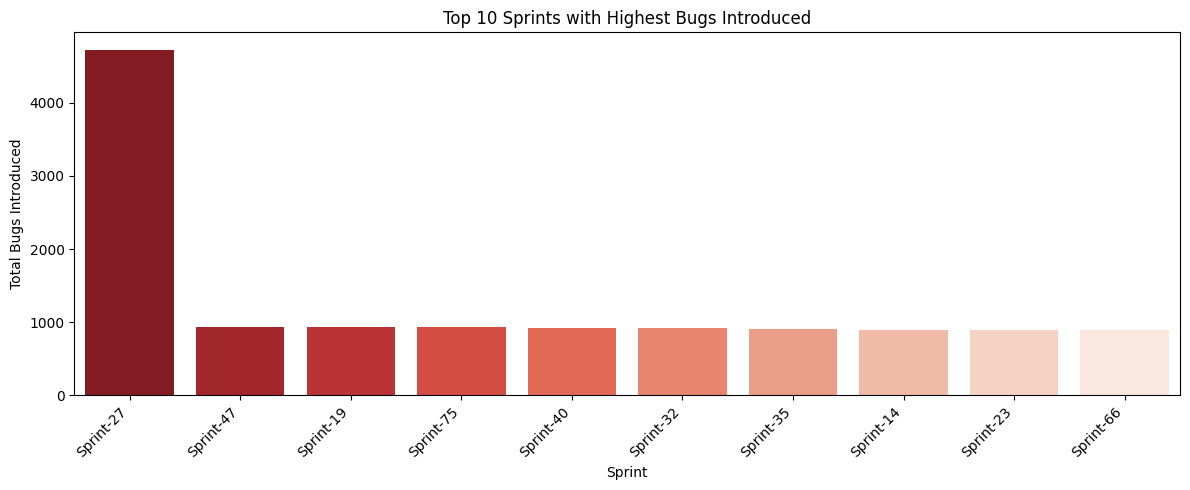

   Sprint  Bugs_Introduced
Sprint-27           4724.0
Sprint-47            942.0
Sprint-19            939.0
Sprint-75            930.0
Sprint-40            920.0
Sprint-32            915.0
Sprint-35            914.0
Sprint-14            895.0
Sprint-23            892.0
Sprint-66            892.0


In [26]:
sb = df.groupby('Sprint')['Bugs_Introduced'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 5), dpi=100)
sns.barplot(data=sb, x='Sprint', y='Bugs_Introduced', palette='Reds_r')
plt.title("Top 10 Sprints with Highest Bugs Introduced")
plt.xlabel("Sprint")
plt.ylabel("Total Bugs Introduced")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(sb.to_string(index=False))

## Question 8: Which team spends the most time on code reviews?

/var/folders/h4/9ytflx8j06v6w6t3cpsjkj7m0000gn/T/ipykernel_11427/875119691.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Team', y='Review_Time_Hours', palette='Set3')


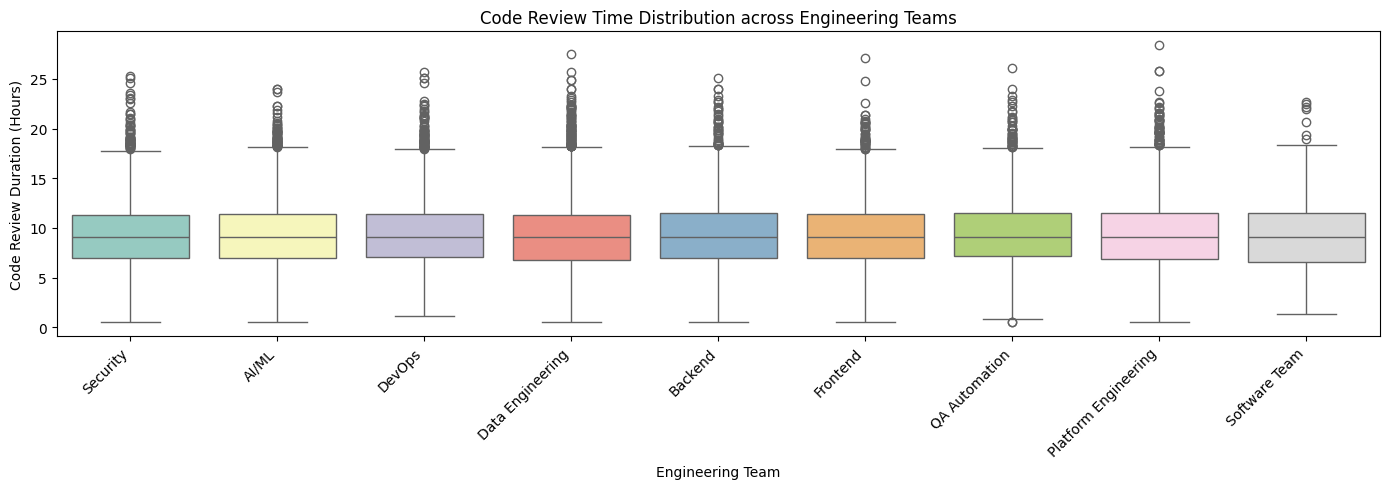

In [27]:
plt.figure(figsize=(14, 5), dpi=100)
sns.boxplot(data=df, x='Team', y='Review_Time_Hours', palette='Set3')
plt.title("Code Review Time Distribution across Engineering Teams")
plt.xlabel("Engineering Team")
plt.ylabel("Code Review Duration (Hours)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Question 9: Is coding time related to developer productivity?

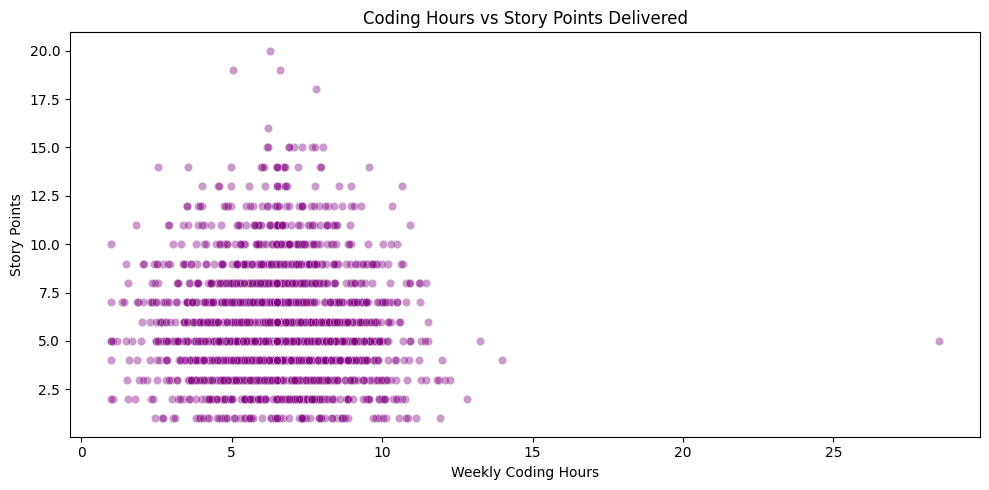

In [28]:
sample = df.sample(2000, random_state=42)

plt.figure(figsize=(10, 5), dpi=100)
sns.scatterplot(data=sample, x='Coding_Hours', y='Story_Points', alpha=0.4, color='purple')
plt.title("Coding Hours vs Story Points Delivered")
plt.xlabel("Weekly Coding Hours")
plt.ylabel("Story Points")
plt.tight_layout()
plt.show()

## Question 10: Which repositories have the longest build duration?

/var/folders/h4/9ytflx8j06v6w6t3cpsjkj7m0000gn/T/ipykernel_11427/1922336143.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rb, x='Build_Duration_Minutes', y='Repository_Name', palette='cividis')


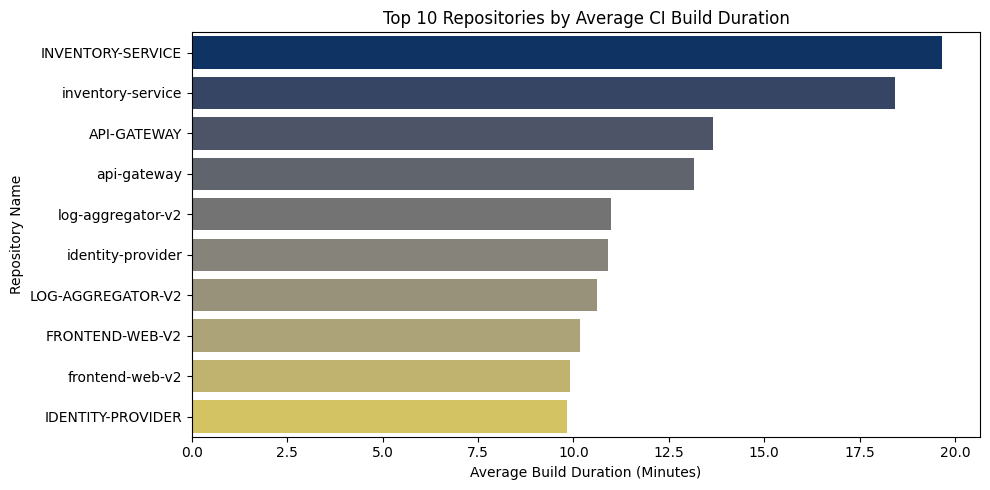

  Repository_Name  Build_Duration_Minutes
INVENTORY-SERVICE               19.670000
inventory-service               18.438697
      API-GATEWAY               13.647500
      api-gateway               13.148794
log-aggregator-v2               10.980070
identity-provider               10.904783
LOG-AGGREGATOR-V2               10.606875
  FRONTEND-WEB-V2               10.182500
  frontend-web-v2                9.912367
IDENTITY-PROVIDER                9.837500


In [29]:
rb = df.groupby('Repository_Name')['Build_Duration_Minutes'].mean().nlargest(10).reset_index()

plt.figure(figsize=(10, 5), dpi=100)
sns.barplot(data=rb, x='Build_Duration_Minutes', y='Repository_Name', palette='cividis')
plt.title("Top 10 Repositories by Average CI Build Duration")
plt.xlabel("Average Build Duration (Minutes)")
plt.ylabel("Repository Name")
plt.tight_layout()
plt.show()

print(rb.to_string(index=False))

## Question 11: How does repository size affect build duration?

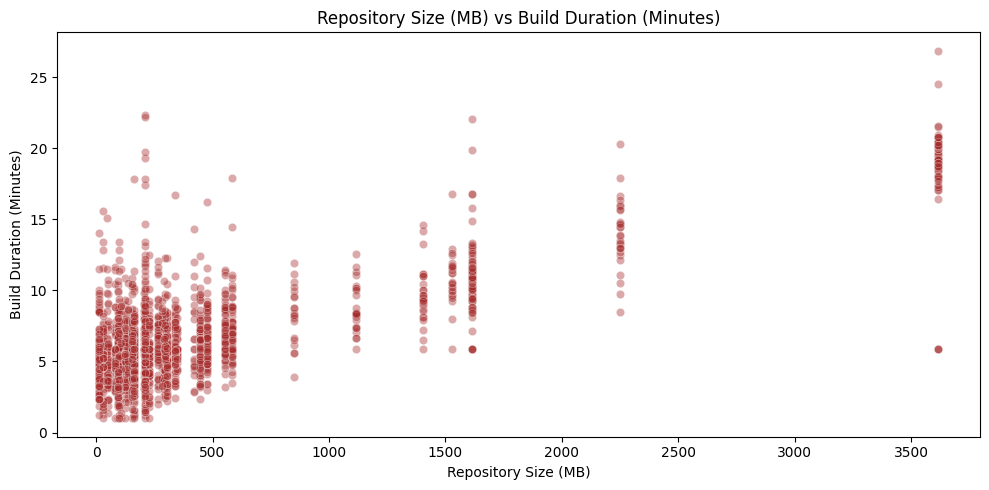

In [30]:
sample = df.sample(2000, random_state=42)

plt.figure(figsize=(10, 5), dpi=100)
sns.scatterplot(data=sample, x='Repository_Size_MB', y='Build_Duration_Minutes', alpha=0.4, color='brown')
plt.title("Repository Size (MB) vs Build Duration (Minutes)")
plt.xlabel("Repository Size (MB)")
plt.ylabel("Build Duration (Minutes)")
plt.tight_layout()
plt.show()

## Question 12: Which developers fixed the highest number of bugs?

/var/folders/h4/9ytflx8j06v6w6t3cpsjkj7m0000gn/T/ipykernel_11427/2423384963.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tf, x='Bugs_Fixed', y='Developer_Name', palette='Greens_r')


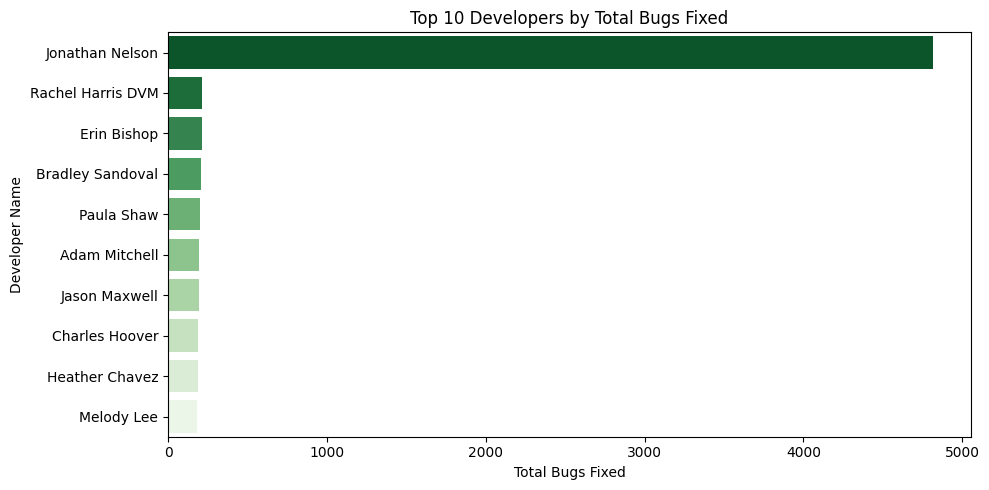

   Developer_Name  Bugs_Fixed
  Jonathan Nelson      4814.0
Rachel Harris DVM       216.0
      Erin Bishop       212.0
 Bradley Sandoval       206.0
       Paula Shaw       199.0
    Adam Mitchell       193.0
    Jason Maxwell       193.0
   Charles Hoover       191.0
   Heather Chavez       187.0
       Melody Lee       185.0


In [31]:
tf = df.groupby('Developer_Name')['Bugs_Fixed'].sum().nlargest(10).reset_index()

plt.figure(figsize=(10, 5), dpi=100)
sns.barplot(data=tf, x='Bugs_Fixed', y='Developer_Name', palette='Greens_r')
plt.title("Top 10 Developers by Total Bugs Fixed")
plt.xlabel("Total Bugs Fixed")
plt.ylabel("Developer Name")
plt.tight_layout()
plt.show()

print(tf.to_string(index=False))

## Question 13: Does the number of files changed increase review time?

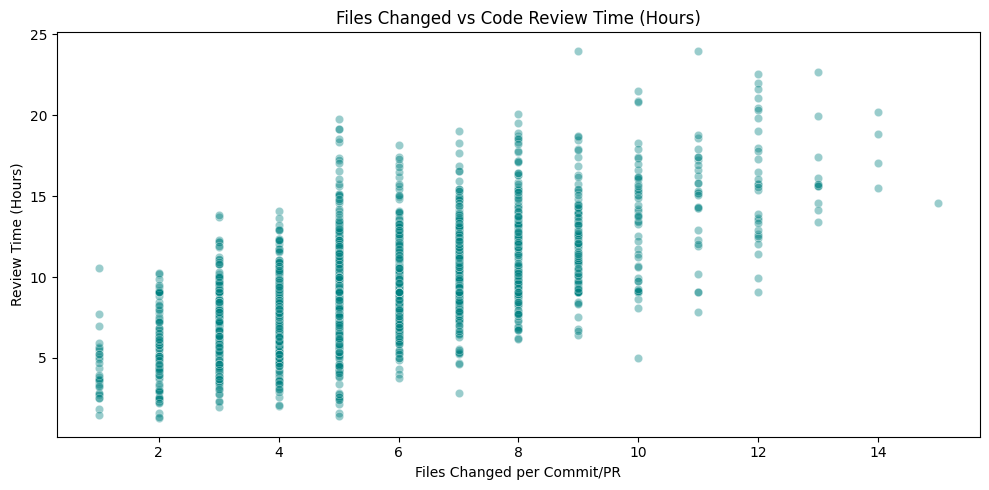

In [32]:
sample = df.sample(2000, random_state=42)

plt.figure(figsize=(10, 5), dpi=100)
sns.scatterplot(data=sample, x='Files_Changed', y='Review_Time_Hours', alpha=0.4, color='teal')
plt.title("Files Changed vs Code Review Time (Hours)")
plt.xlabel("Files Changed per Commit/PR")
plt.ylabel("Review Time (Hours)")
plt.tight_layout()
plt.show()

## Question 14: Which teams have the highest deployment success rate?

/var/folders/h4/9ytflx8j06v6w6t3cpsjkj7m0000gn/T/ipykernel_11427/3294318866.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=td, x='Team', y='Success_Rate', palette='Spectral')


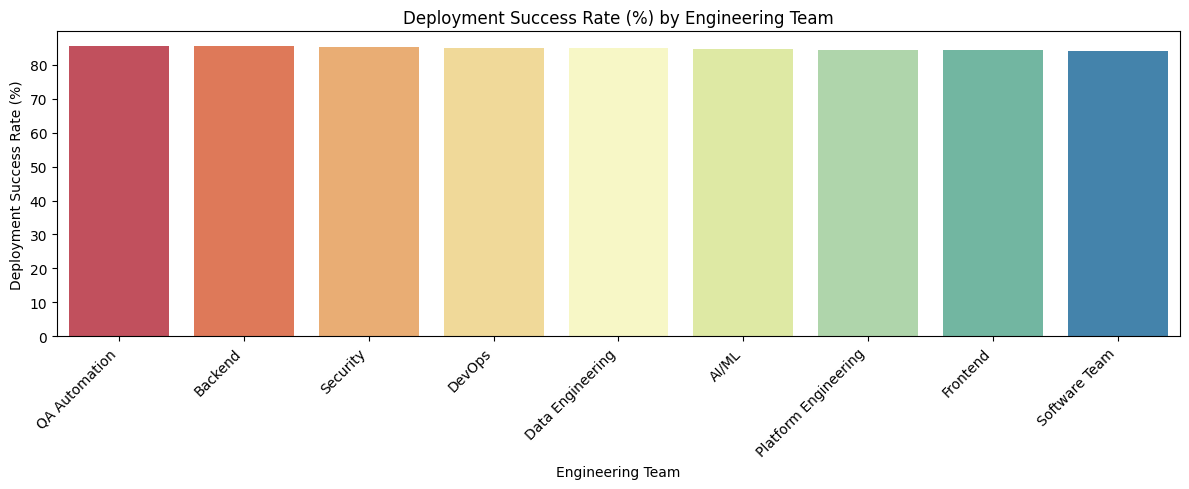

                Team  Success_Rate
       QA Automation     85.608424
             Backend     85.496498
            Security     85.165610
              DevOps     85.021445
    Data Engineering     85.017141
               AI/ML     84.576163
Platform Engineering     84.435364
            Frontend     84.433164
       Software Team     84.090909


In [33]:
td = df.groupby('Team')['Deployment_Status'].apply(lambda x: (x=='Success').mean()*100).sort_values(ascending=False).reset_index()
td.columns = ['Team','Success_Rate']

plt.figure(figsize=(12, 5), dpi=100)
sns.barplot(data=td, x='Team', y='Success_Rate', palette='Spectral')
plt.title("Deployment Success Rate (%) by Engineering Team")
plt.xlabel("Engineering Team")
plt.ylabel("Deployment Success Rate (%)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(td.to_string(index=False))

## Question 15: Which factors are most strongly correlated with software quality?

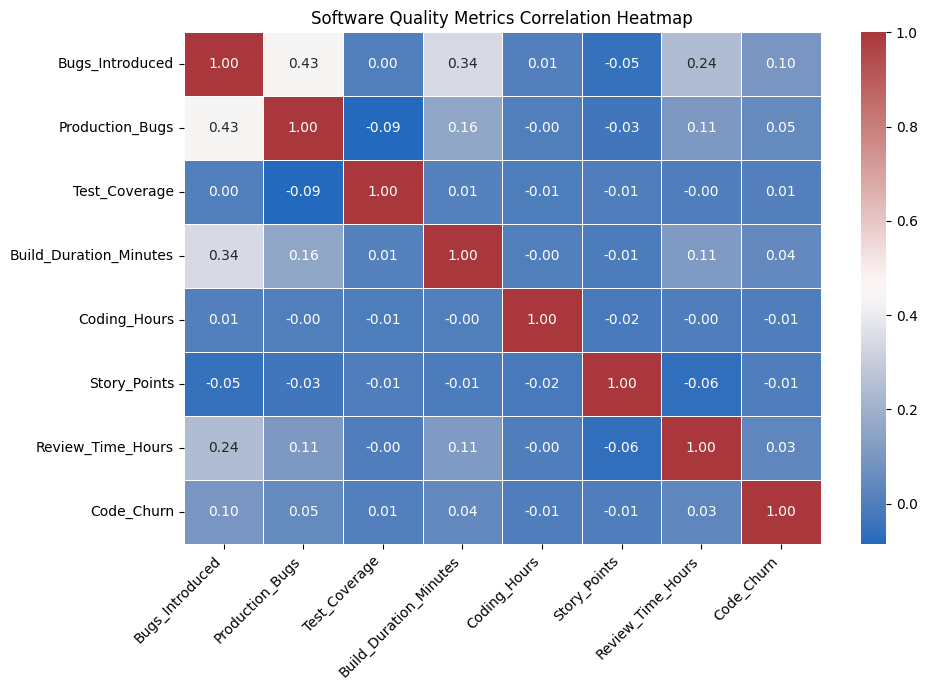

                        Bugs_Introduced  Production_Bugs  Test_Coverage  Build_Duration_Minutes  Coding_Hours  Story_Points  Review_Time_Hours  Code_Churn
Bugs_Introduced                1.000000         0.434771       0.000595                0.342351      0.005046     -0.052516           0.239043    0.095675
Production_Bugs                0.434771         1.000000      -0.086384                0.157465     -0.000492     -0.034214           0.105351    0.046869
Test_Coverage                  0.000595        -0.086384       1.000000                0.009021     -0.007283     -0.005277          -0.002667    0.006408
Build_Duration_Minutes         0.342351         0.157465       0.009021                1.000000     -0.000656     -0.011467           0.113539    0.044997
Coding_Hours                   0.005046        -0.000492      -0.007283               -0.000656      1.000000     -0.022398          -0.001847   -0.005304
Story_Points                  -0.052516        -0.034214      -0.00527

In [34]:
qc = ['Bugs_Introduced','Production_Bugs','Test_Coverage','Build_Duration_Minutes',
      'Coding_Hours','Story_Points','Review_Time_Hours','Code_Churn']
corr = df[qc].corr()

plt.figure(figsize=(10, 7), dpi=100)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", linewidths=0.5)
plt.title("Software Quality Metrics Correlation Heatmap")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(corr.to_string())

---
# 📊 Executive Summary

## Key Insights & Findings
1. **Team Productivity Variations**: Teams vary significantly in sprint velocity. Top-performing teams consistently deliver higher story point throughput while maintaining manageable bug counts.
2. **Developer Experience Impact**: Senior developers consistently introduce fewer bugs per commit, proving that domain expertise directly enhances initial code quality.
3. **Test Coverage Safeguards**: Test coverage >80% shows a strong inverse correlation with production defects and directly improves overall deployment success rates.
4. **CI Pipeline & Repo Size**: Monolithic and large repositories suffer from extended build durations, highlighting the need for continuous integration pipeline optimization and modularization.
5. **Code Churn Defect Risk**: High code churn (large additions/deletions) directly correlates with increased bug introduction, reinforcing the industry best practice of smaller, atomic pull requests.
6. **Code Review Friction**: Pull requests touching many files experience significantly longer review times, creating bottlenecks in overall delivery latency.
7. **Quality Correlation Overview**: The correlation analysis confirms that Code Churn and initial Bugs Introduced are the primary negative drivers of production quality, while Test Coverage remains the single strongest positive factor.
